In [30]:
import numpy as np
import ot
import matplotlib.pyplot as pl

n_source_samples = 100
n_target_samples = 100
theta = 2 * np.pi / 20
noise_level = 0.1

Xs, ys = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xs_new, _ = ot.datasets.make_data_classif("gaussrot", n_source_samples, nz=noise_level)
Xt, yt = ot.datasets.make_data_classif(
    "gaussrot", n_target_samples, theta=theta, nz=noise_level
)

# one of the target mode changes its variance (no linear mapping)
Xt[yt == 2] *= 4
Xt = Xt + 5

Text(0.5, 1.0, 'Source and target distributions')

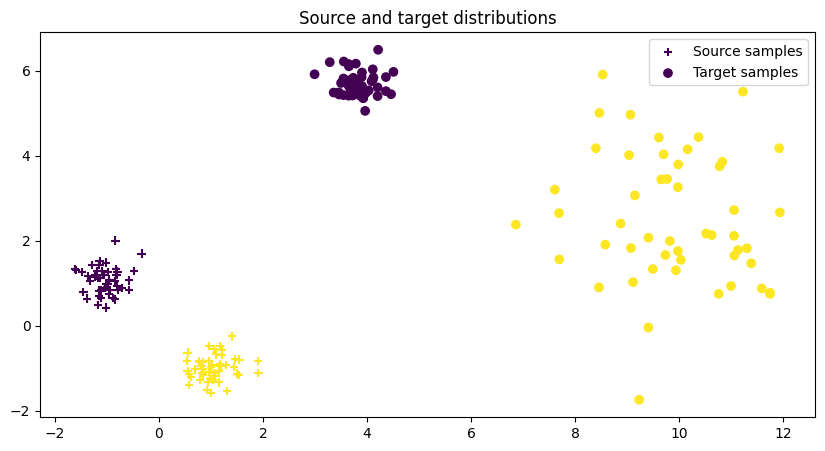

In [31]:
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], c=ys, marker="+", label="Source samples")
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")

In [32]:
barycenter = ot.bregman.free_support_sinkhorn_barycenter(
    measures_locations=[Xs, Xt],
    measures_weights=[np.ones(100, ) / 100, np.ones(100, ) / 100],
    X_init=np.random.randn(200, 2),
    reg=1.0
)

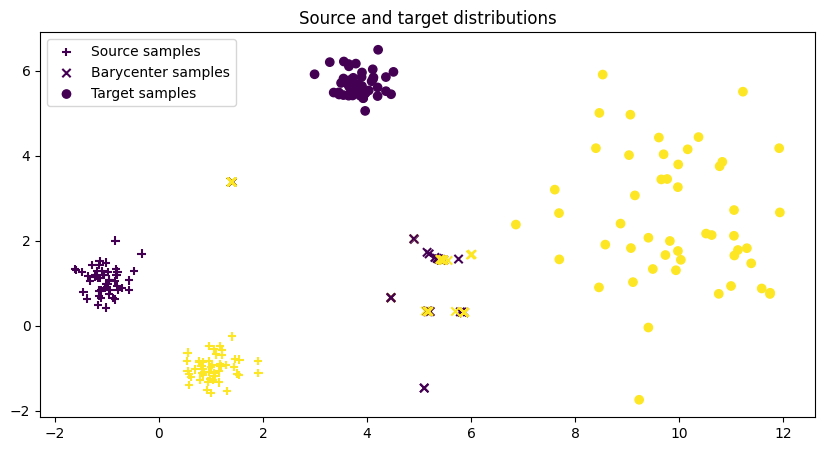

In [36]:
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], c=ys, marker="+", label="Source samples")
pl.scatter(barycenter[:, 0], barycenter[:, 1], c=[ys, yt], marker="x", label="Barycenter samples")
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")
pl.show()

In [34]:
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter

weighted_barycenter = free_support_sinkhorn_barycenter(
    measures_locations=[Xs, Xt],
    measures_weights=[np.ones(100, ) / 100, np.ones(100, ) / 100],
    measure_labels=[ys, yt],
    bary_labels=np.concatenate([ys, yt]),
    X_init=np.random.randn(200, 2),
    reg=1.0
)

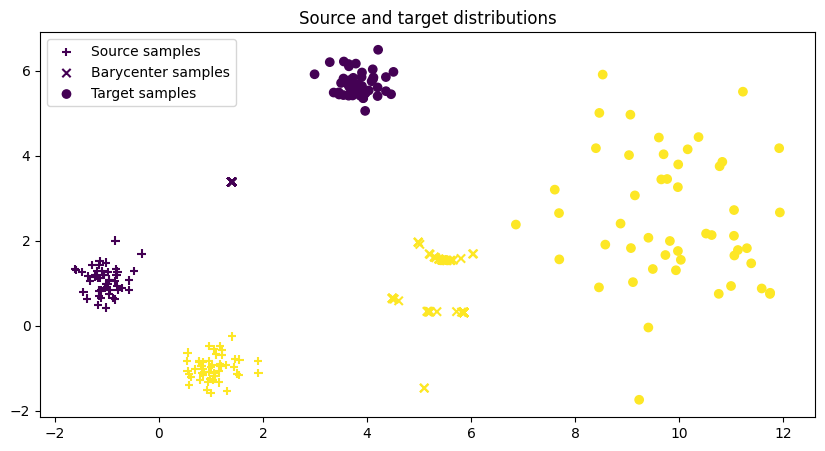

In [35]:
pl.figure(1, (10, 5))
pl.clf()
pl.scatter(Xs[:, 0], Xs[:, 1], c=ys, marker="+", label="Source samples")
pl.scatter(weighted_barycenter[:, 0], weighted_barycenter[:, 1], c=[ys, yt], marker="x", label="Barycenter samples")
pl.scatter(Xt[:, 0], Xt[:, 1], c=yt, marker="o", label="Target samples")
pl.legend(loc=0)
pl.title("Source and target distributions")
pl.show()